In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os

os.chdir(r'C:/Users/aruna/Desktop/Work/MLDAY1')

iris = load_iris()
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df['species']=iris.target
print(df.shape)
print(df.head())




(150, 5)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


In [5]:
# pretend we don't know labels
X = df.drop(columns=['species'])

# scale the data first — important for KMeans
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)

(150, 4)


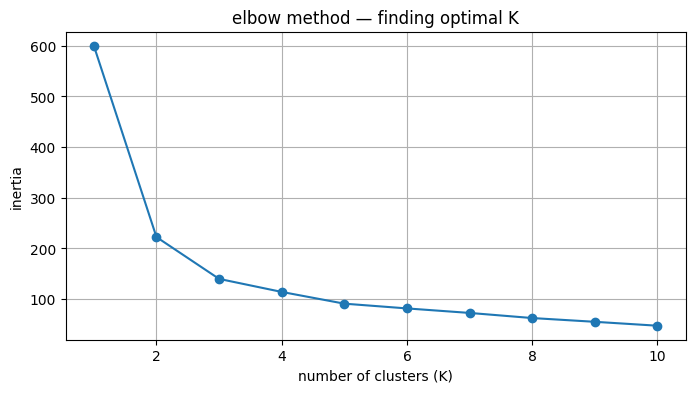

In [6]:
# find optimal number of clusters — elbow method
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('number of clusters (K)')
plt.ylabel('inertia')
plt.title('elbow method — finding optimal K')
plt.grid(True)
plt.show()

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

df['cluster'] = kmeans.labels_

# compare clusters vs actual species
print(pd.crosstab(df['species'], df['cluster']))

cluster   0   1   2
species            
0         0  50   0
1        39   0  11
2        14   0  36


Variance explained: 95.81%


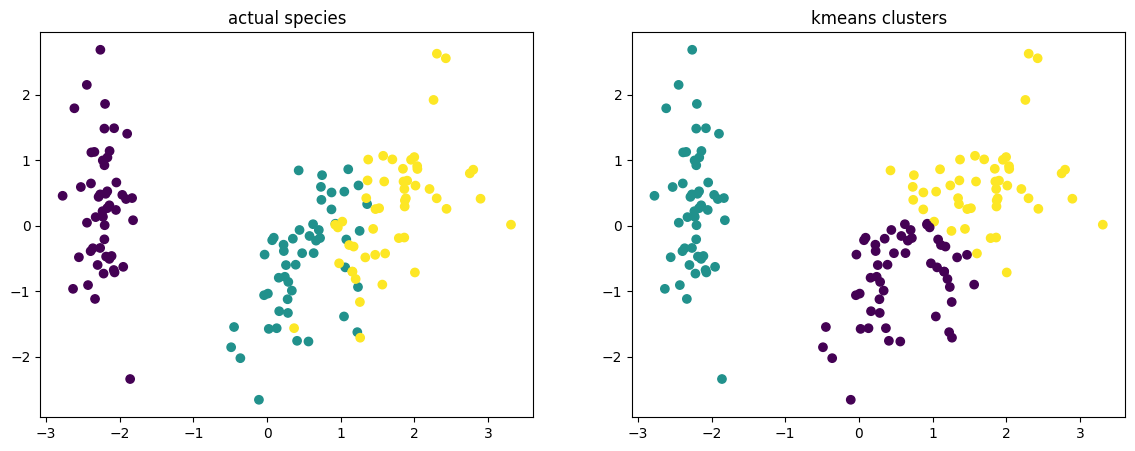

In [8]:
# reduce 4D to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained: {pca.explained_variance_ratio_.sum():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# actual species
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df['species'], cmap='viridis')
axes[0].set_title('actual species')

# kmeans clusters
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='viridis')
axes[1].set_title('kmeans clusters')

plt.show()